# Case study E6: AC optimal power flow (PGLib-OPF, JuMP, ExaModels)

The ExaModels paper benchmarks AC optimal power flow on PGLib-OPF cases through Ipopt with several
modelling layers. Its point is that evaluating the model's derivatives takes 45 to 70% of the solve
with JuMP or AMPL, and about 5% with ExaModels, whose "SIMD abstraction" evaluates each repeated
constraint pattern as one kernel: the same idea as Scaly's vectorized gathers and `vmap`.

This study runs rosetta-opf's two models, JuMP (`jump.jl`) and ExaModels (`examodels.jl`), against the
same model written in Scaly, all three through the same Ipopt (3.14.19) with MUMPS, and compares
iterations, objectives, where the time goes, and the time to a first solution. The Scaly cells run
without Julia; the sweep's recorded results are in `results/`. The write-up is
`internal/notes/case_study_e6_report.html`.

In [1]:
import json
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
sys.path[:0] = [str(HERE), str(HERE.parents[1] / "notebooks")]

import plotstyle
import scaly as sc

import scaly_impl as si

plotstyle.use()
RUN_BASELINES = False  # True reruns compare.py (JuMP, ExaModels, Scaly on seven cases, two tolerances); needs baseline/setup.sh
RESULTS = HERE / "results"

## The model

rosetta-opf states the AC-OPF as PowerModels' reference model does: voltage angle and magnitude per
bus, active and reactive generation per generator, and the flows at both ends of every branch as
variables; the generators' quadratic costs; the reference angle, a power balance per bus and four
flow equations per branch as equalities; the angle-difference window and the thermal limit at both
ends of each branch as inequalities. `scaly_impl.problem` writes every term for all buses, generators
or branches at once: `sc.gather` reads each branch's end voltages and flows, `sc.segment_sum` adds each
bus's flows and generation.

The data are the case as PowerModels processes it (`baseline/export_case.jl` writes it, with every
collection in the order JuMP's model iterates it); two small cases are stored in `results/cases/`.

In [2]:
case = si.load_case(RESULTS / "cases" / "case118_ieee.json")
print(f"{case.name}: {case.n_bus} buses, {case.n_gen} generators, {case.n_branch} branches")
prob = si.problem(case)
print(f"{sum(a.size for a in si.start(case))} variables, {prob.n_eq} equalities, {prob.n_ineq} inequalities")

pglib_opf_case118_ieee: 118 buses, 54 generators, 186 branches
1088 variables, 981 equalities, 558 inequalities


## Solving it

`sc.solver(problem, "ipopt")` generates the model's value, gradient, constraint Jacobian and Lagrangian
Hessian as C, with the sparsity found by Scaly, and links them to Ipopt. The first call compiles.

In [3]:
for name in ("case14_ieee", "case118_ieee"):
  c = si.load_case(RESULTS / "cases" / f"{name}.json")
  p = si.problem(c)
  t0 = time.perf_counter()
  solve = sc.solver(p, "ipopt", name=f"nb_{name}", options={"tol": 1e-8, "linear_solver": "mumps"})
  x0 = si.start(c)
  zeros = tuple(np.zeros_like(a) for a in x0)
  solve(x0, zeros, np.zeros(p.n_eq), np.zeros(p.n_ineq), ())
  first = time.perf_counter() - t0
  t0 = time.perf_counter()
  (va, vm, pg, qg, pf, qf), *_ = solve(x0, zeros, np.zeros(p.n_eq), np.zeros(p.n_ineq), ())
  again = time.perf_counter() - t0
  st = sc.solver_stats(solve)
  print(f"{name}: {st.to_solver_status().name}, {st.iter} iterations, objective {st.obj:.6f}; first solve {first:.1f} s, then {1e3 * again:.1f} ms "
        f"(Ipopt {1e3 * st.t_total:.1f} ms, function evaluations {1e3 * st.t_fe:.1f} ms)")

case14_ieee: OK, 15 iterations, objective 2178.080411; first solve 1.3 s, then 6.1 ms (Ipopt 6.0 ms, function evaluations 0.0 ms)


case118_ieee: OK, 29 iterations, objective 97213.606939; first solve 2.3 s, then 35.4 ms (Ipopt 35.2 ms, function evaluations 2.4 ms)


PGLib-OPF's reported AC optima are 2.1781e+03 for case14 and 9.7214e+04 for case118. The recorded
sweep below shows JuMP and ExaModels reaching the same objectives in the same number of iterations.

A check independent of the formulation: the power-flow mismatch at the solution from the bus
admittance matrix, built from the case's branch data (pi model with tap and phase shift).

In [4]:
def mismatch(c, va, vm, pg, qg):
  n = c.n_bus
  Y = np.zeros((n, n), dtype=complex)
  for k in range(c.n_branch):
    y = c.g[k] + 1j * c.b[k]
    tap = c.tr[k] + 1j * c.ti[k]
    yfr, yto = c.g_fr[k] + 1j * c.b_fr[k], c.g_to[k] + 1j * c.b_to[k]
    f, t = c.f[k], c.t[k]
    Y[f, f] += (y + yfr) / abs(tap) ** 2
    Y[t, t] += y + yto
    Y[f, t] += -y / np.conj(tap)
    Y[t, f] += -y / tap
  V = vm * np.exp(1j * va)
  S = V * np.conj(Y @ V)
  gen = np.zeros(n, dtype=complex)
  np.add.at(gen, c.gen_bus, pg + 1j * qg)
  shunt = (c.gs - 1j * c.bs) * vm**2
  return np.abs(S - (gen - (c.pd + 1j * c.qd) - shunt)).max()


print(f"case118 power-flow mismatch at Scaly's solution: {mismatch(case, va, vm, pg, qg):.1e} p.u.")

case118 power-flow mismatch at Scaly's solution: 2.1e-10 p.u.


## The sweep

`compare.py` runs, per case and tolerance, rosetta-opf's `jump.jl` (unmodified), its `examodels.jl`
(with ExaModels 0.12's names for the same calls) and `run_scaly.py`, each in a fresh process that
solves the case twice and records the second solve. All three are timed by Ipopt's own timing
statistics, parsed the same way from each process's output.

In [5]:
if RUN_BASELINES:
  subprocess.run([sys.executable, str(HERE / "compare.py"), "--out", str(RESULTS / "sweep.json")], check=True)
rows = json.loads((RESULTS / "sweep.json").read_text())["rows"]
TOL = 1e-8
cases = []
for r in rows:
  if r["tol"] == TOL and r["case"] not in cases:
    cases.append(r["case"])


def get(case, stack, tol=TOL):
  return next(r for r in rows if r["case"] == case and r["stack"] == stack and r["tol"] == tol)


print(f"{'case':18s} {'stack':10s} {'iter':>5s} {'objective':>16s} {'Ipopt s':>9s} {'f.eval s':>9s} {'share':>6s}")
for c in cases:
  for s in ("jump", "examodels", "scaly"):
    r = get(c, s)
    t = r["timing"]
    print(f"{c:18s} {s:10s} {r['iterations']:5d} {r['objective']:16.6f} {t['OverallAlgorithm']:9.3f} {t['Function Evaluations']:9.3f} {t['Function Evaluations'] / t['OverallAlgorithm']:6.0%}")

case               stack       iter        objective   Ipopt s  f.eval s  share
case14_ieee        jump          15      2178.080411     0.004     0.001    25%
case14_ieee        examodels     15      2178.080411     0.004     0.000     0%
case14_ieee        scaly         15      2178.080411     0.005     0.000     0%
case118_ieee       jump          29     97213.606939     0.051     0.017    33%
case118_ieee       examodels     29     97213.606940     0.035     0.002     6%
case118_ieee       scaly         29     97213.606939     0.036     0.003     8%
case300_ieee       jump          33    565219.971865     0.134     0.048    36%
case300_ieee       examodels     33    565219.972403     0.098     0.006     6%
case300_ieee       scaly         33    565219.971865     0.088     0.006     7%
case1354_pegase    jump          49   1258843.985101     1.250     0.588    47%
case1354_pegase    examodels     49   1258843.986594     0.700     0.042     6%
case1354_pegase    scaly         49   12

/var/folders/mc/38r0ggmx49l2jwwk6k9nc63h0000gn/T/ipykernel_38304/3927952276.py:17: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0.06, 1, 1))


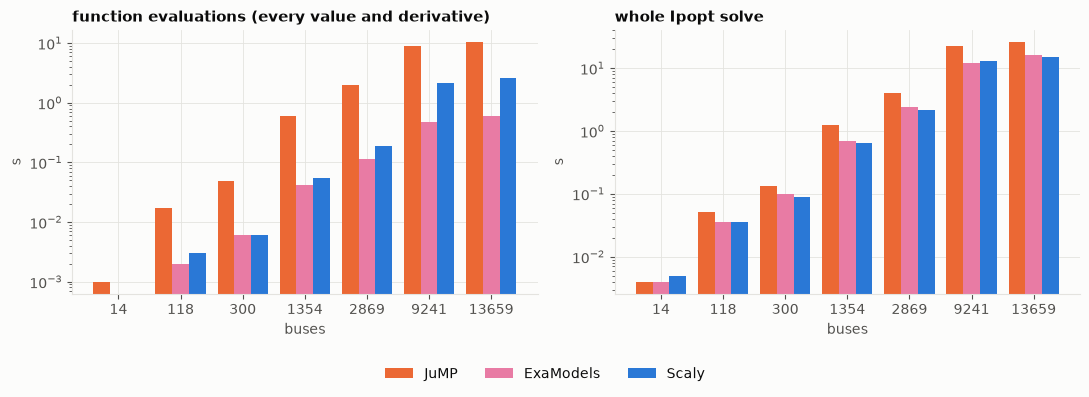

In [6]:
colors = {"jump": "C1", "examodels": "C4", "scaly": "C0"}
names = {"jump": "JuMP", "examodels": "ExaModels", "scaly": "Scaly"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
x = np.arange(len(cases))
for i, s in enumerate(("jump", "examodels", "scaly")):
  fe = [get(c, s)["timing"]["Function Evaluations"] for c in cases]
  total = [get(c, s)["timing"]["OverallAlgorithm"] for c in cases]
  axes[0].bar(x + (i - 1) * 0.27, fe, 0.27, color=colors[s], label=names[s])
  axes[1].bar(x + (i - 1) * 0.27, total, 0.27, color=colors[s], label=names[s])
for ax, title in zip(axes, ("function evaluations (every value and derivative)", "whole Ipopt solve")):
  ax.set_yscale("log")
  ax.set_xticks(x, [c.split("_")[0].removeprefix("case") for c in cases])
  ax.set_xlabel("buses")
  ax.set_ylabel("s")
  ax.set_title(title)
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

## Time to a first solution

From a fresh process to the first solve's end: Julia's package load and compile of the model code
(rosetta-opf's warm-up case compiles it), against Scaly's import, model build, C generation and
compile.

/var/folders/mc/38r0ggmx49l2jwwk6k9nc63h0000gn/T/ipykernel_38304/4156889370.py:15: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


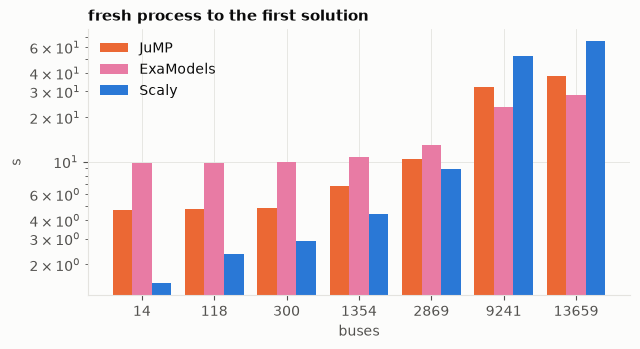

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for i, s in enumerate(("jump", "examodels", "scaly")):
  vals = []
  for c in cases:
    r = get(c, s)
    own = r["own"]
    vals.append(own["t_import"] + own["t_build"] + own["first_call"] if s == "scaly" else own["t_warmup_process"] + own["first_call"])
  ax.bar(x + (i - 1) * 0.27, vals, 0.27, color=colors[s], label=names[s])
ax.set_yscale("log")
ax.set_xticks(x, [c.split("_")[0].removeprefix("case") for c in cases])
ax.set_xlabel("buses")
ax.set_ylabel("s")
ax.set_title("fresh process to the first solution")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Findings

- **The same solves**: identical Ipopt iterations on every case (JuMP one fewer on case13659) and the
  same objectives, from the same data and the same Ipopt build.
- **Derivatives**: Scaly's function evaluations are 10.6 to 10.7x below JuMP's at case1354 and
  case2869 and within 1.3x of ExaModels' up to case1354. From there Scaly falls behind ExaModels,
  4.4x at case9241 and case13659: it evaluates the Hessian by colouring, and the colour width follows
  the largest bus degree (12 at case118, 74 at case9241), so the work grows as variables x colours;
  ExaModels' per-pattern local Hessians grow as nonzeros (CS-5).
- **The whole solve**: Scaly and ExaModels are level, both 1.4 to 2x faster than JuMP; the linear
  solver is most of what remains.
- **Setup**: Scaly reaches a first solution fastest up to case2869 and slowest from case9241, where the
  same colour width makes 277 MB of C (12 s to render, 22 s to compile).